## 1. Load the Dataset

In this step, I will import the pandas library and load the food delivery dataset.
Pandas will be used for data loading, cleaning, and analysis.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Food_Delivery_Times.csv')

df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


## 2. Check Rows and Columns

In this step, I will check the number of rows and columns in the dataset.
This gives a basic understanding of the size of the dataset.

In [ ]:
print(f'This Dataset has {df.shape[0]} rows and {df.shape[1]} columns.')

This Dataset has 1000 rows and 9 columns.


## 4. Dataset Information

In this step, I will check the data types and basic information about each column.
This will help me understand which columns are numerical and which are categorical.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


## 5. Check Missing Values

In this step, I will check for missing values in each column.
Missing values need to be identified before further analysis because they can affect the results.

In [ ]:
missing_values = df.isnull().sum()

print(missing_values)

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


## 6. Check Missing Value Percentage

In this step, I will calculate the percentage of missing values in each column.
This will help me understand how much missing data is present.

In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

Order_ID                  0.0
Distance_km               0.0
Weather                   3.0
Traffic_Level             3.0
Time_of_Day               3.0
Vehicle_Type              0.0
Preparation_Time_min      0.0
Courier_Experience_yrs    3.0
Delivery_Time_min         0.0
dtype: float64


## 7. Check Duplicate Records

In this step, I will check whether the dataset contains any duplicate rows.
Duplicate records can affect the accuracy of the analysis.

In [ ]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


## 8. Statistical Summary

In this step, I will generate summary statistics for the numerical columns.
This helps me understand the distribution, average, minimum, maximum, and spread of the data.

In [ ]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


## 9. Check Unique Values

In this step, I will check the unique values in the categorical columns.
This will help me understand the different weather, traffic, time, and vehicle categories in the dataset.

In [ ]:
print("Weather:", df["Weather"].unique())
print("Traffic Level:", df["Traffic_Level"].unique())
print("Time of Day:", df["Time_of_Day"].unique())
print("Vehicle Type:", df["Vehicle_Type"].unique())

Weather: ['Windy' 'Clear' 'Foggy' 'Rainy' 'Snowy' nan]
Traffic Level: ['Low' 'Medium' 'High' nan]
Time of Day: ['Afternoon' 'Evening' 'Night' 'Morning' nan]
Vehicle Type: ['Scooter' 'Bike' 'Car']


## 10. Handle Missing Values

In this step, I will fill the missing values in the categorical columns using the most common value.
For courier experience, I will use the median value.
This will allow me to continue the analysis without removing the records.

In [ ]:
# Fill categorical missing values with the most common value
for column in ["Weather", "Traffic_Level", "Time_of_Day"]:
    df[column] = df[column].fillna(df[column].mode()[0])

# Fill missing courier experience with the median
df["Courier_Experience_yrs"] = df["Courier_Experience_yrs"].fillna(
    df["Courier_Experience_yrs"].median()
)

print(df.isnull().sum())

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


## 11. Check Cleaned Dataset

In this step, I will check the first few rows of the cleaned dataset.
This helps confirm that the data is ready for further analysis.

In [ ]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


## 12. Calculate Basic Logistics KPIs

In this step, I will calculate some important logistics KPIs.
These KPIs will help me understand delivery performance and operational efficiency.

In [ ]:
average_delivery_time = df["Delivery_Time_min"].mean()
average_distance = df["Distance_km"].mean()
average_preparation_time = df["Preparation_Time_min"].mean()
average_courier_experience = df["Courier_Experience_yrs"].mean()

print("Average Delivery Time:", round(average_delivery_time, 2), "minutes")
print("Average Delivery Distance:", round(average_distance, 2), "km")
print("Average Preparation Time:", round(average_preparation_time, 2), "minutes")
print("Average Courier Experience:", round(average_courier_experience, 2), "years")

Average Delivery Time: 56.73 minutes
Average Delivery Distance: 10.06 km
Average Preparation Time: 16.98 minutes
Average Courier Experience: 4.59 years


## 13. Delivery Time by Weather

In this step, I will compare the average delivery time under different weather conditions.
This will help me understand whether weather conditions are associated with differences in delivery time.

In [ ]:
weather_delivery_time = df.groupby("Weather")["Delivery_Time_min"].mean().sort_values(ascending=False)

print(weather_delivery_time.round(2))

Weather
Snowy    67.11
Rainy    59.79
Foggy    59.47
Windy    55.46
Clear    53.15
Name: Delivery_Time_min, dtype: float64


## 14. Delivery Time by Traffic Level

In this step, I will compare the average delivery time for different traffic levels.
This will help me understand how traffic conditions are associated with delivery time.

In [ ]:
traffic_delivery_time = df.groupby("Traffic_Level")["Delivery_Time_min"].mean().sort_values(ascending=False)

print(traffic_delivery_time.round(2))

Traffic_Level
High      64.81
Medium    56.45
Low       52.89
Name: Delivery_Time_min, dtype: float64


## 15. Delivery Time by Vehicle Type

In this step, I will compare the average delivery time for different vehicle types.
This will help me understand delivery performance across vehicles.

In [ ]:
vehicle_delivery_time = df.groupby("Vehicle_Type")["Delivery_Time_min"].mean().sort_values(ascending=False)

print(vehicle_delivery_time.round(2))

Vehicle_Type
Car        58.20
Bike       56.57
Scooter    56.05
Name: Delivery_Time_min, dtype: float64


## 16. Delivery Time by Time of Day

In this step, I will compare the average delivery time during different times of the day.
This will help me understand whether delivery time changes during different periods.

In [ ]:
time_delivery = df.groupby("Time_of_Day")["Delivery_Time_min"].mean().sort_values(ascending=False)

print(time_delivery.round(2))

Time_of_Day
Evening      57.48
Morning      57.01
Afternoon    56.08
Night        55.21
Name: Delivery_Time_min, dtype: float64


## 17. Distance and Delivery Time

In this step, I will compare delivery distance with delivery time.
This will help me understand whether longer distances are associated with longer delivery times.

In [ ]:
print(df[["Distance_km", "Delivery_Time_min"]].corr())

                   Distance_km  Delivery_Time_min
Distance_km           1.000000           0.780998
Delivery_Time_min     0.780998           1.000000


## 18. Preparation Time and Delivery Time

In this step, I will check the relationship between preparation time and delivery time.
This will help me understand whether longer preparation times are associated with longer delivery times.

In [ ]:
print(df[["Preparation_Time_min", "Delivery_Time_min"]].corr())

                      Preparation_Time_min  Delivery_Time_min
Preparation_Time_min               1.00000            0.30735
Delivery_Time_min                  0.30735            1.00000


## 19. Courier Experience and Delivery Time

In this step, I will check the relationship between courier experience and delivery time.
This will help me understand whether courier experience is associated with delivery performance.

In [ ]:
print(df[["Courier_Experience_yrs", "Delivery_Time_min"]].corr())

                        Courier_Experience_yrs  Delivery_Time_min
Courier_Experience_yrs                1.000000          -0.089111
Delivery_Time_min                    -0.089111           1.000000


## 20. Visualize Delivery Time by Traffic

In this step, I will create a bar chart to compare average delivery time across different traffic levels.
This will make the results easier to understand visually.

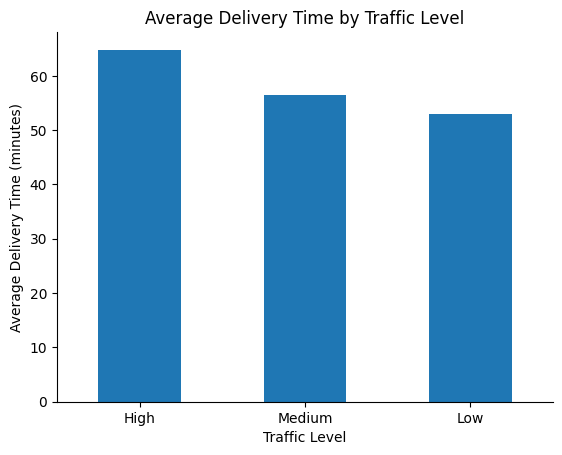

In [ ]:
import matplotlib.pyplot as plt

traffic_delivery_time.plot(kind="bar")

plt.title("Average Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

## 21. Visualize Delivery Time by Weather

In this step, I will create a bar chart to compare average delivery time under different weather conditions.
This will help me understand how weather conditions are associated with delivery time.

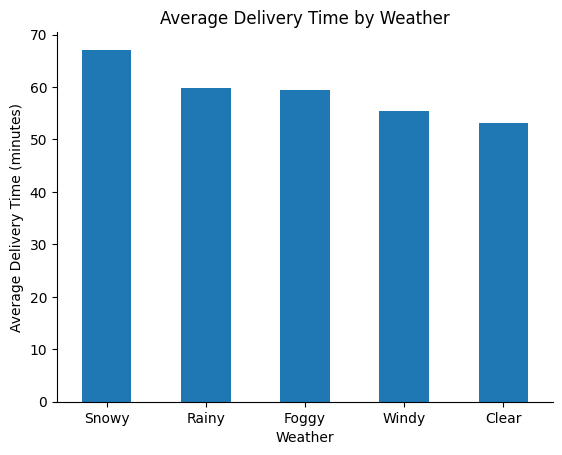

In [ ]:
weather_delivery_time.plot(kind="bar")

plt.title("Average Delivery Time by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.gca().spines[['top','right']].set_visible(False)
plt.show()


## 22. Distance vs Delivery Time

In this step, I will create a scatter plot to visualize the relationship between delivery distance and delivery time.
This will help me understand whether longer distances are associated with longer delivery times.

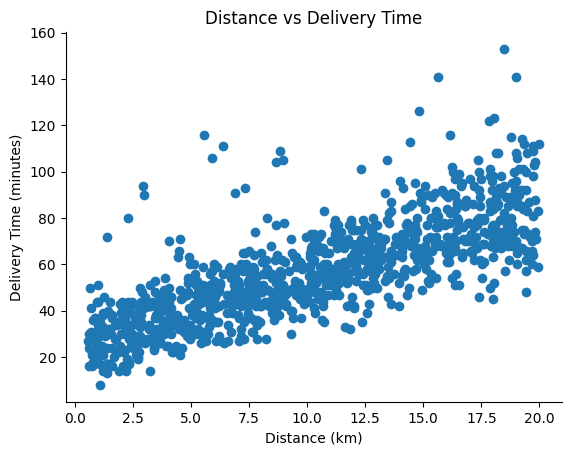

In [ ]:
plt.scatter(df["Distance_km"], df["Delivery_Time_min"])

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

## 23. Visualize Delivery Time by Vehicle Type

In this step, I will create a bar chart to compare the average delivery time for different vehicle types.
This will help me compare delivery performance across vehicles.

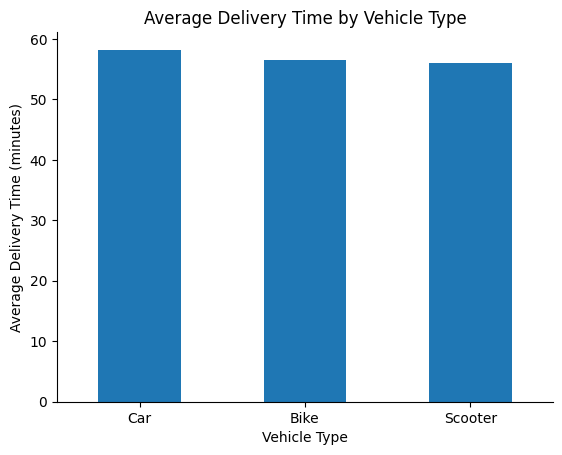

In [ ]:
vehicle_delivery_time.plot(kind="bar")

plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

## 24. Visualize Delivery Time by Time of Day

In this step, I will create a bar chart to compare the average delivery time during different times of the day.
This will help me understand delivery patterns throughout the day.

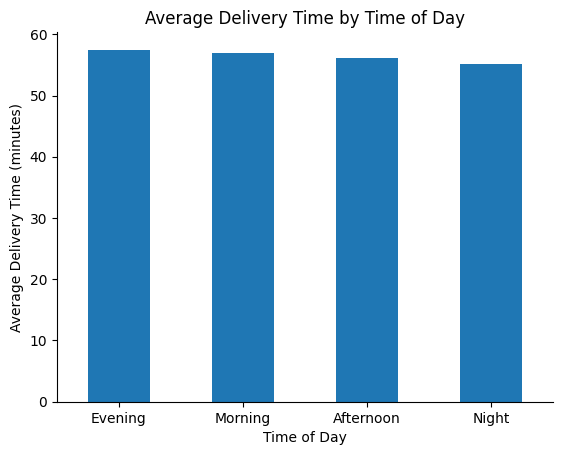

In [ ]:
time_delivery.plot(kind="bar")

plt.title("Average Delivery Time by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

## 25. Prepare Data for Predictive Analysis

In this step, I will select the important columns for predicting delivery time.
Delivery time will be the target variable, while the other operational factors will be used as input variables.

In [ ]:
X = df.drop(["Delivery_Time_min", "Order_ID"], axis=1)
y = df["Delivery_Time_min"]


## 26. Encode Categorical Data

In this step, I will convert categorical variables into numerical values.
Traffic Level is ordinal because Low, Medium, and High have a natural order.
Weather, Time of Day, and Vehicle Type are nominal because their categories do not have a natural order.

In [ ]:
# Create a copy of the input data
X = df.drop(["Delivery_Time_min", "Order_ID"], axis=1)

# Ordinal encoding for Traffic Level
traffic_mapping = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

X["Traffic_Level"] = X["Traffic_Level"].map(traffic_mapping)

# One-hot encoding for nominal columns
X = pd.get_dummies(
    X,
    columns=["Weather", "Time_of_Day", "Vehicle_Type"],
    drop_first=True
)

y = df["Delivery_Time_min"]

print(X.head())

   Distance_km  Traffic_Level  Preparation_Time_min  Courier_Experience_yrs  \
0         7.93              1                    12                     1.0   
1        16.42              2                    20                     2.0   
2         9.52              1                    28                     1.0   
3         7.44              2                     5                     1.0   
4        19.03              1                    16                     5.0   

   Weather_Foggy  Weather_Rainy  Weather_Snowy  Weather_Windy  \
0          False          False          False           True   
1          False          False          False          False   
2           True          False          False          False   
3          False           True          False          False   
4          False          False          False          False   

   Time_of_Day_Evening  Time_of_Day_Morning  Time_of_Day_Night  \
0                False                False              False   
1 

## 28. Split Training and Testing Data

In this step, I will divide the data into training and testing sets.
The training data will be used to build the model, while the testing data will be used to evaluate the model.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 800
Testing rows: 200


## 29. Train Linear Regression Model

In this step, I will train a Linear Regression model to predict delivery time.
The model will learn the relationship between the input variables and delivery time from the training data.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## 30. Make Predictions

In this step, I will use the trained model to predict delivery time for the testing data.
These predictions will later be compared with the actual delivery times.

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[35.31414947 66.45562321 44.70005971 43.83647765 80.06036637 32.19413449
 69.30990931 32.33978748 37.5450251  78.14345944]


## 31. Evaluate the Model

In this step, I will evaluate the performance of the Linear Regression model.
MAE shows the average prediction error in minutes, while R² shows how well the model explains the delivery time data.

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("R² Score:", round(r2, 2))

Mean Absolute Error: 5.9
R² Score: 0.83


## 32. Compare Actual and Predicted Delivery Time

In this step, I will compare the actual delivery times with the predicted delivery times.
This will help me understand how closely the model predictions match the actual values.

In [ ]:
comparison = pd.DataFrame({
    "Actual_Delivery_Time": y_test.values,
    "Predicted_Delivery_Time": y_pred.round(2)
})

comparison.head(10)

,Actual_Delivery_Time,Predicted_Delivery_Time
0,32,35.31
1,68,66.46
2,39,44.70
3,44,43.84
4,85,80.06
5,31,32.19
6,77,69.31
7,33,32.34
8,90,37.55
9,91,78.14


## 33. Visualize Actual vs Predicted Delivery Time

In this step, I will create a scatter plot to compare actual delivery times with predicted delivery times.
This will help me visually check the model's prediction performance.

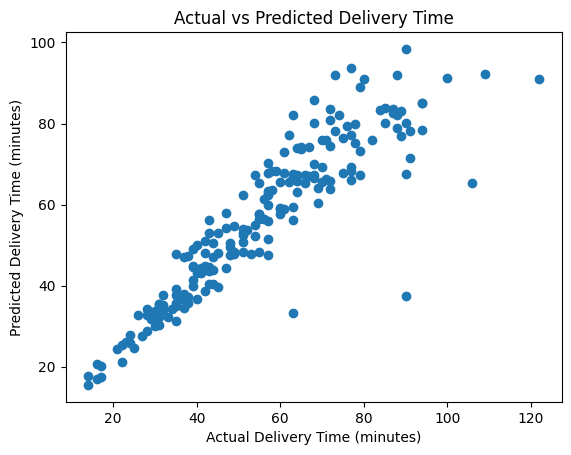

In [ ]:
plt.scatter(y_test, y_pred)

plt.title("Actual vs Predicted Delivery Time")
plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.show()

## 34. Final Project Findings

The main findings from the analysis are:

* Average delivery time is **56.73 minutes**.
* Average delivery distance is **10.06 km**.
* Average preparation time is **16.98 minutes**.
* Average courier experience is **4.59 years**.
* Deliveries during **high traffic** had a higher average delivery time than low traffic.
* **Snowy weather** had the highest average delivery time among the weather categories.
* Distance had a strong positive relationship with delivery time.
* Preparation time had a moderate positive relationship with delivery time.
* Courier experience had a very weak relationship with delivery time.
* The Linear Regression model had an **MAE of 5.9 minutes** and an **R² score of 0.83**.


## 35. Conclusion

In this project, I used Python to analyze food delivery data and understand delivery performance. I calculated important KPIs and explored how factors such as distance, traffic, weather, preparation time, and courier experience are related to delivery time.

The analysis showed that distance and traffic have noticeable relationships with delivery time, while weather conditions also affect average delivery performance. I also built a simple Linear Regression model to predict delivery time. The model achieved an MAE of 5.9 minutes and an R² score of 0.83 on the test data.

These findings can help a logistics company improve delivery planning and resource allocation. For more advanced route optimization, additional information such as GPS locations, routes, vehicle capacity, and delivery stops would be required.
